## Volatility Forecasting Using GARCH Models

In this project, we aim to forecast financial market volatility using GARCH models. We'll use S&P 500 daily return data and apply various diagnostic tests and forecasting techniques to build and evaluate a volatility model.


In [1]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

from data_loader import load_data
from visualize import plot_log_returns, plot_squared_returns
from modeling import fit_garch_model, forecast_garch, get_aic_bic, plot_ranking
from tests import (
    ljung_box_test,
    arch_lm_test,
    forecast_errors
)

## Load and inspect data

In [2]:
data = load_data(path="../data/cleaned_data.csv")
data.head()

,price,log_return
Date,,
2015-01-05,2020.579956,-0.018447
2015-01-06,2002.609985,-0.008933
2015-01-07,2025.900024,0.011563
2015-01-08,2062.139893,0.017730
2015-01-09,2044.810059,-0.008439


## Visualize returns

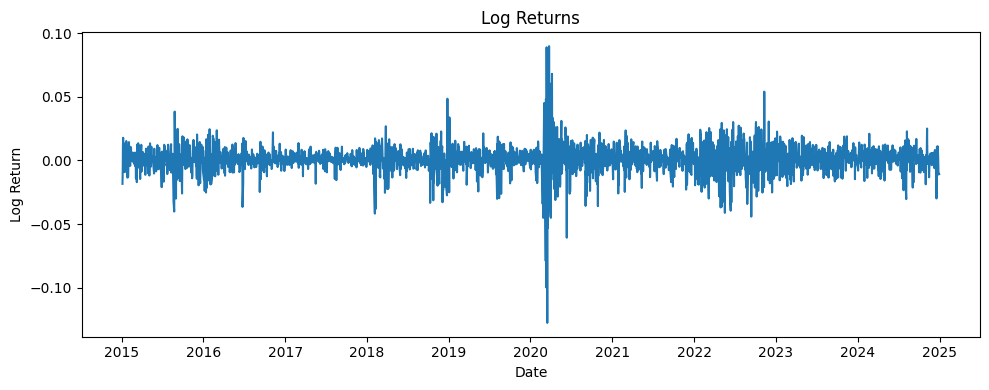

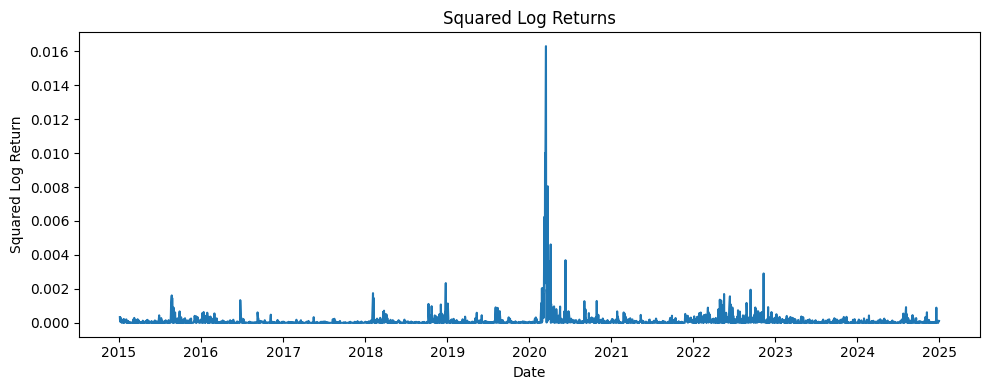

In [3]:
plot_log_returns(data)
plot_squared_returns(data)

## Fit GARCH model

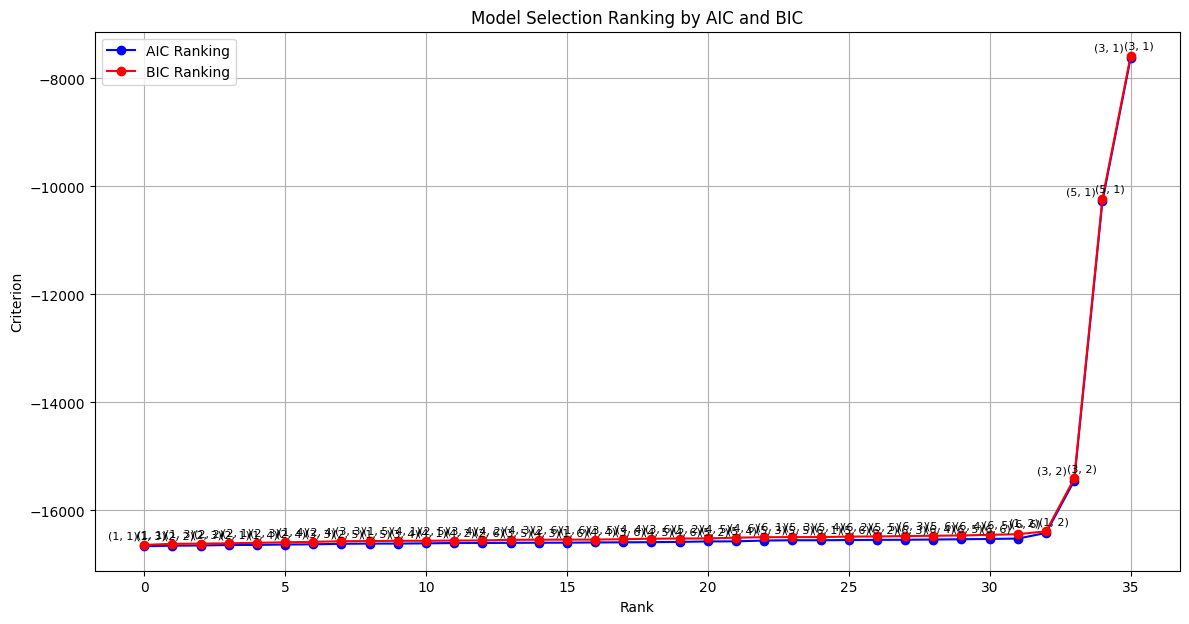

In [4]:

import warnings
warnings.filterwarnings("ignore")

pq_combinations, aic_values, bic_values = get_aic_bic(data['log_return'], max_p=6, max_q=6)
plot_ranking(aic_values, bic_values, pq_combinations)

In [5]:
model_fit = fit_garch_model(data,1,1)
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                8334.96
Distribution:                  Normal   AIC:                          -16661.9
Method:            Maximum Likelihood   BIC:                          -16638.6
                                        No. Observations:                 2514
Date:                Fri, May 02 2025   Df Residuals:                     2513
Time:                        16:33:35   Df Model:                            1
                                 Mean Model                                 
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         8.3305e-04  9.353e-07    890.649      0.000 [8.312e-04,8.349e-04]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      2.5400e-06  1.273e-11  1.995e+05      0.000 [2.540e-06,2.540e-06]
alpha[1]       0.2000  3.174e-02      6.302  2.941e-10     [  0.138,  0.262]
beta[1]        0.7800  2.660e-02     29.319 5.869e-189     [  0.728,  0.832]
============================================================================

Covariance estimator: robust
"""

## Forecast Volatility

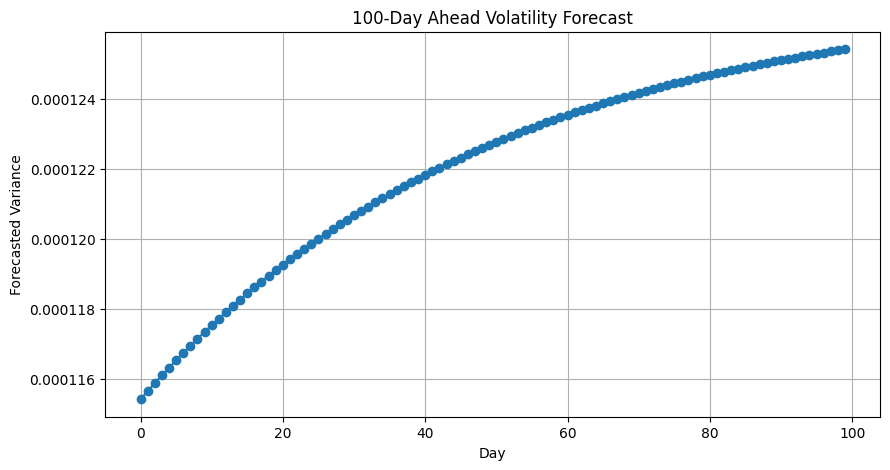

In [6]:
forecasts = forecast_garch(model_fit, steps=100)

## Diagnostics tests

In [7]:
ljb_results = ljung_box_test(model_fit.resid.dropna())
print("Ljung-Box Test Results:")
print(ljb_results)  # Examine the structure of the output


# ARCH LM: Checks for remaining ARCH effects in residuals
arch_test_results = arch_lm_test(model_fit.resid.dropna())
print("\nARCH LM Test Results:")
print(f"LM Stat: {arch_test_results['LM Stat']:.2f}")
print(f"p-value: {arch_test_results['p-value']:.3g}")
print(f"F-Stat: {arch_test_results['F-Stat']:.2f}")
print(f"F p-value: {arch_test_results['F p-value']:.3g}")

Ljung-Box Test Results:
       lb_stat     lb_pvalue
1    45.739720  1.350562e-11
2    61.293420  4.901205e-14
3    62.113169  2.078065e-13
4    71.187804  1.274012e-14
5    76.915175  3.704633e-15
6   108.013562  5.310056e-21
7   164.044833  4.514897e-32
8   204.281360  8.000707e-40
9   251.759214  4.241577e-49
10  262.006013  1.615817e-50

ARCH LM Test Results:
LM Stat: 971.86
p-value: 2.15e-202
F-Stat: 158.14
F p-value: 2.75e-257
